<a href="https://colab.research.google.com/github/TetianaMar-888/Python_for_ds_tasks/blob/main/Marinoshenko_Tetiana_HW_2_5_Time_Series_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

У цьому ДЗ ми попрактикуємось моделювати часові ряди на даних з [Store Item Demand Forecasting Challenge](https://www.kaggle.com/competitions/demand-forecasting-kernels-only/overview). Ми будемо працювати лише з тренувальними даними цього змагання і задача у нас буде дещо змінена. Фокус буде на пошуці найкращої моделі, експериментах і використанні функціоналу `darts`.

Якщо якісно попрацювати в цьому завданні - це буде чудовий приклад проєкту для вашого портфоліо: "спрогнозував(-ла) поденні продажі на 1 міс для 50 товарів в 10 магазинах" звучить вражаюче! Але ми в рамках ДЗ для оптимізації часу сконцентруємось на моделюванні продажів одного товару в одному магазині.

**Задача**

Вам надано дані про продажі товарів у магазинах за 5 років. Хочемо навчитись передачати продажі в наступному місяці поденно кожного з 50 товарів у кожному з 10 магазинів. Відповідно будемо проводити експерименти, аби знайти найкращу модель для цього.

На відміну від змагання, ми будемо використовувати метрику МАРЕ (Mean Absolute Percentage Error) замість SMAPE (Symmetric Mean Absolute Percentage Error). Проте, ви також можете розрахувати SMAPE і подати свої результати через late submission на Kaggle.

1. Завантажуємо дані в Pandas.

  1. Завантажте дані з файлу `train.csv.zip` за допомогою бібліотеки Pandas.
  2. Перетворіть колонку `date` на формат `datetime`.
  3. Встановіть колонку `date` як індекс для датафрейму.
  4. Виведіть перші 10 рядків отриманого датафрейму та інформацію про датафрейм.

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import pyplot as plt
import plotly.express as px
from matplotlib.gridspec import GridSpec

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_predict

In [ ]:
# Завантажуємо дані
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/2.6.train.csv.zip')
data['date'] = pd.to_datetime(data['date'])
data.set_index('date', inplace=True)
print(data.head(10))
print(data.info())

            store  item  sales
date                          
2013-01-01      1     1     13
2013-01-02      1     1     11
2013-01-03      1     1     14
2013-01-04      1     1     13
2013-01-05      1     1     10
2013-01-06      1     1     12
2013-01-07      1     1     10
2013-01-08      1     1      9
2013-01-09      1     1     12
2013-01-10      1     1      9
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 913000 entries, 2013-01-01 to 2017-12-31
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   store   913000 non-null  int64
 1   item    913000 non-null  int64
 2   sales   913000 non-null  int64
dtypes: int64(3)
memory usage: 27.9 MB
None


  2. Давайте трошки зрозуміємо дані. У нас 10 магазинів і 50 айтемів в кожному. Хочемо зрозуміти, чи відрізняється динаміка по кожному айтему в магазинах. Як би ви це візуалізували? Побудуйте 3 графіка, які вам допоможуть. Можна використати будь-який інструмент: matplotlib, seaborn, plotly.

  Напишіть висновок з побудованих вами візуалізацій.
  
    **Підказка**: я б спробувала вивести середнє значення і довірчий інтервал (який включає весь діапазон значень з різних магазинів) для динаміки кожного айтема, або принаймні для декількох айтемів, аби зрозуміти тенденцію.



In [ ]:
data

,store,item,sales
date,,,
2013-01-01,1,1,13
2013-01-02,1,1,11
2013-01-03,1,1,14
2013-01-04,1,1,13
2013-01-05,1,1,10
...,...,...,...
2017-12-27,10,50,63
2017-12-28,10,50,59
2017-12-29,10,50,74


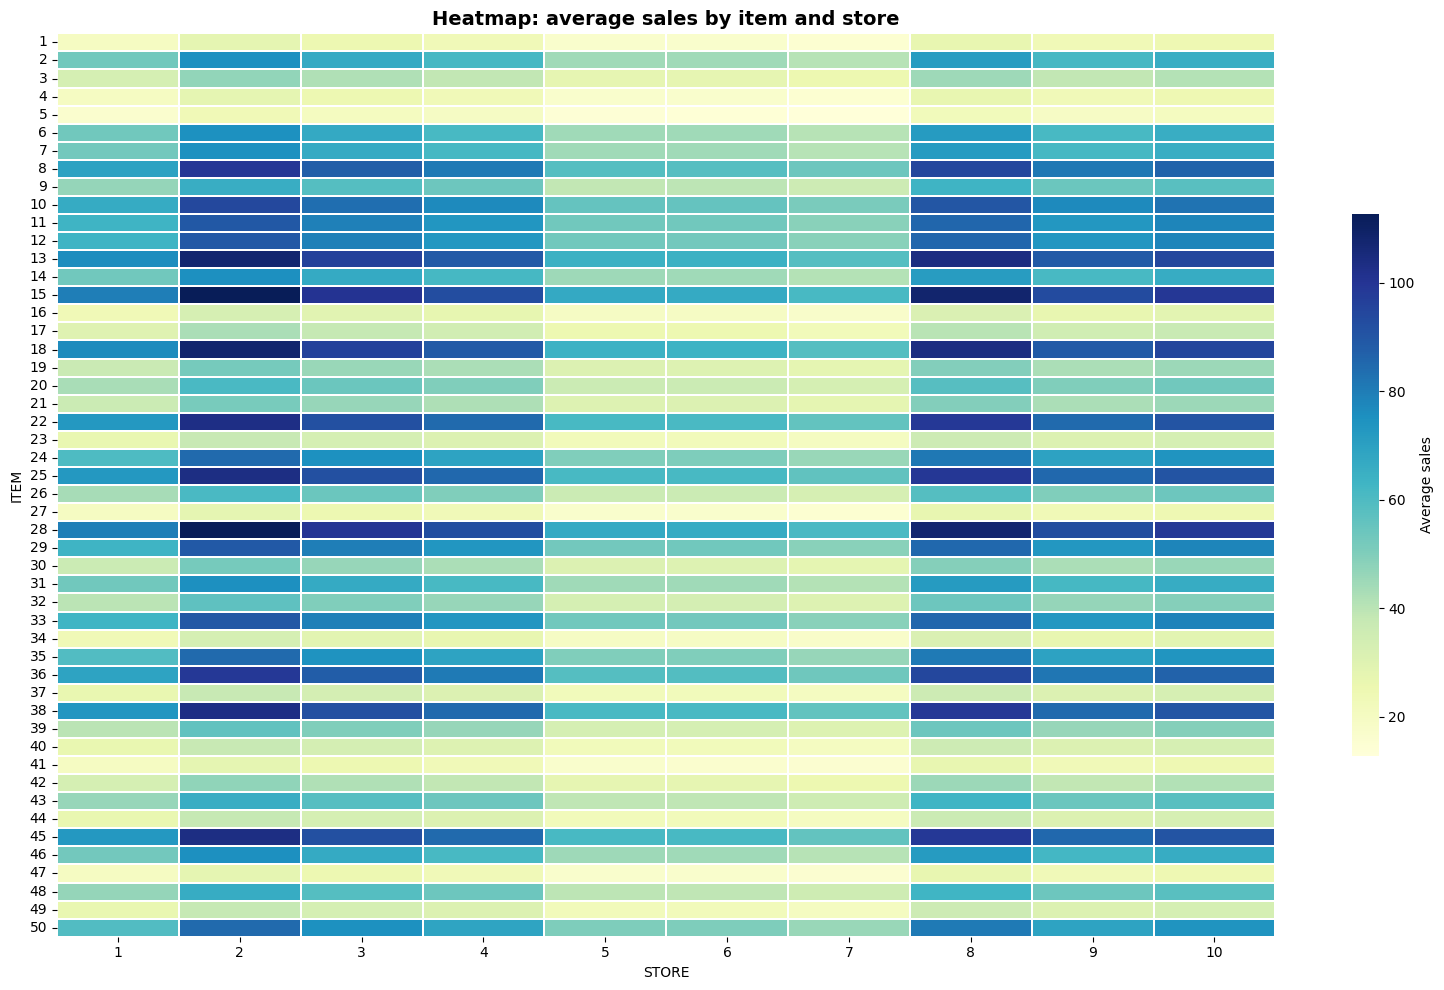

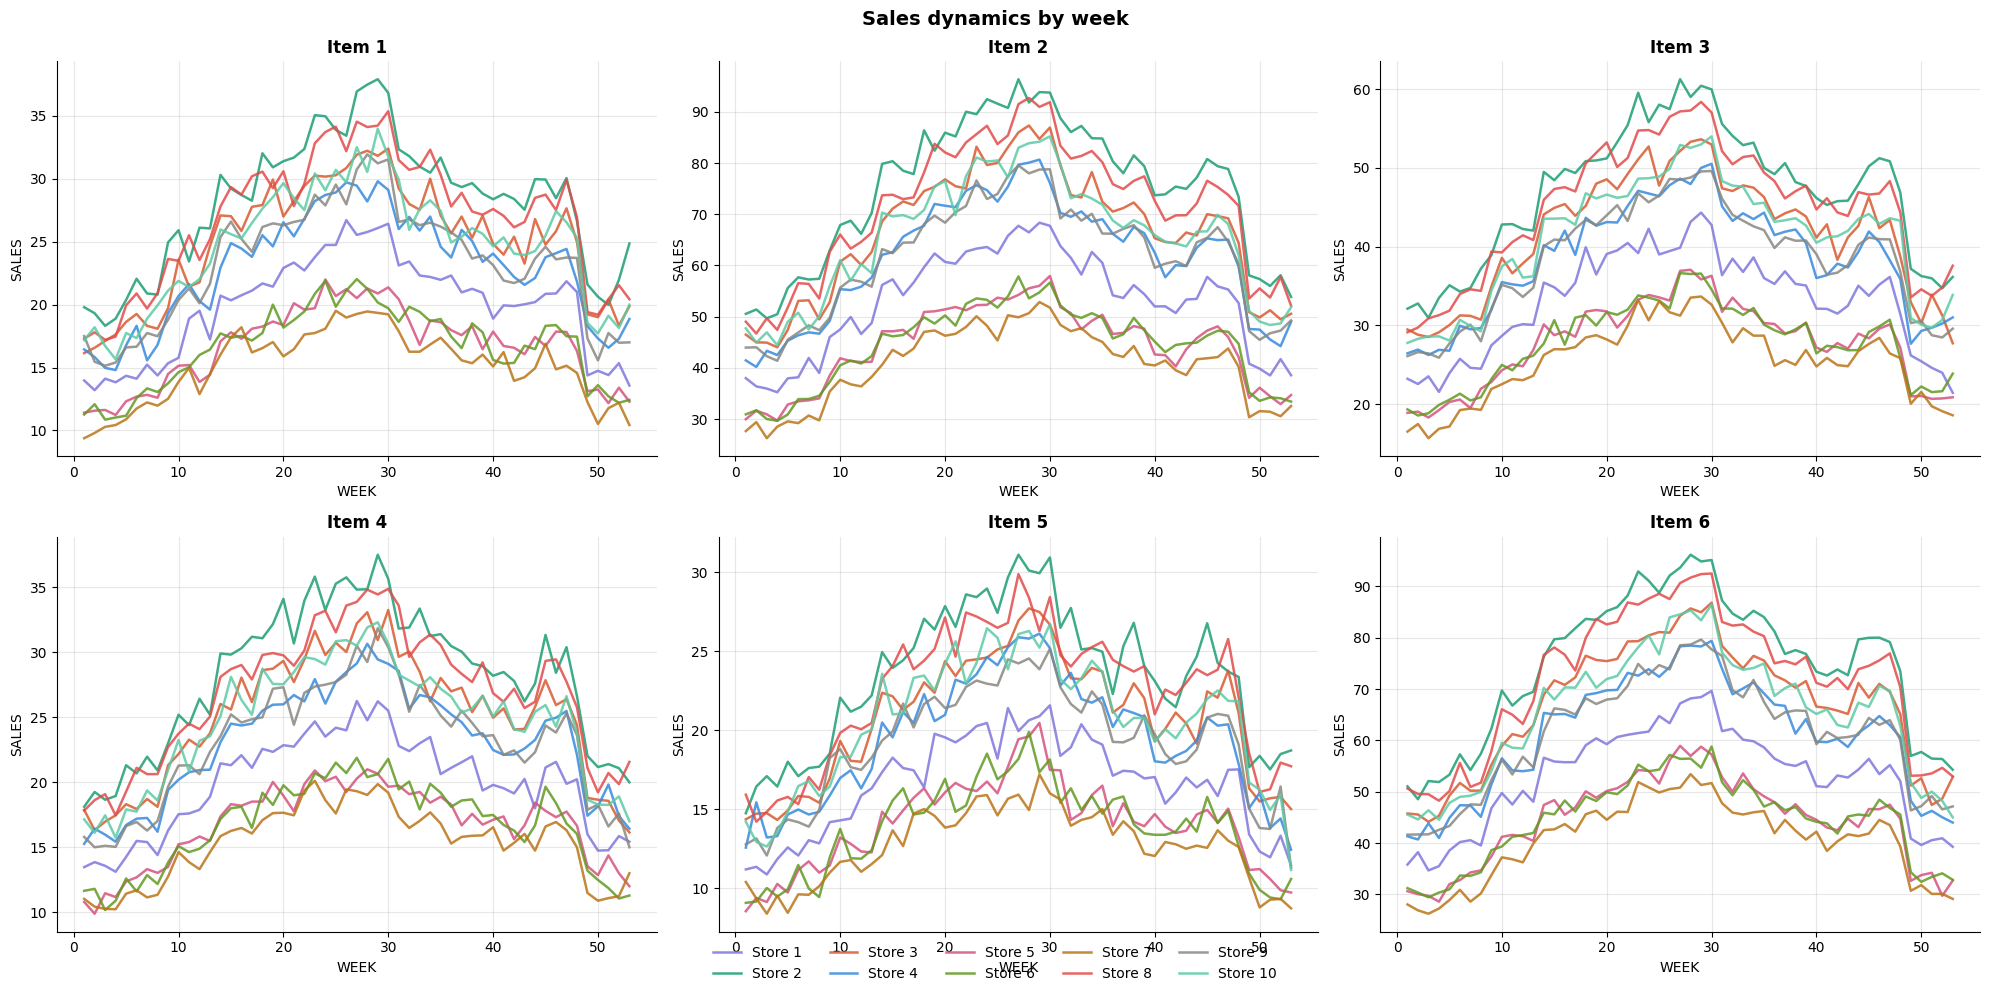

/tmp/ipykernel_17513/3028794645.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x="store", y="sales", palette=PALETTE)


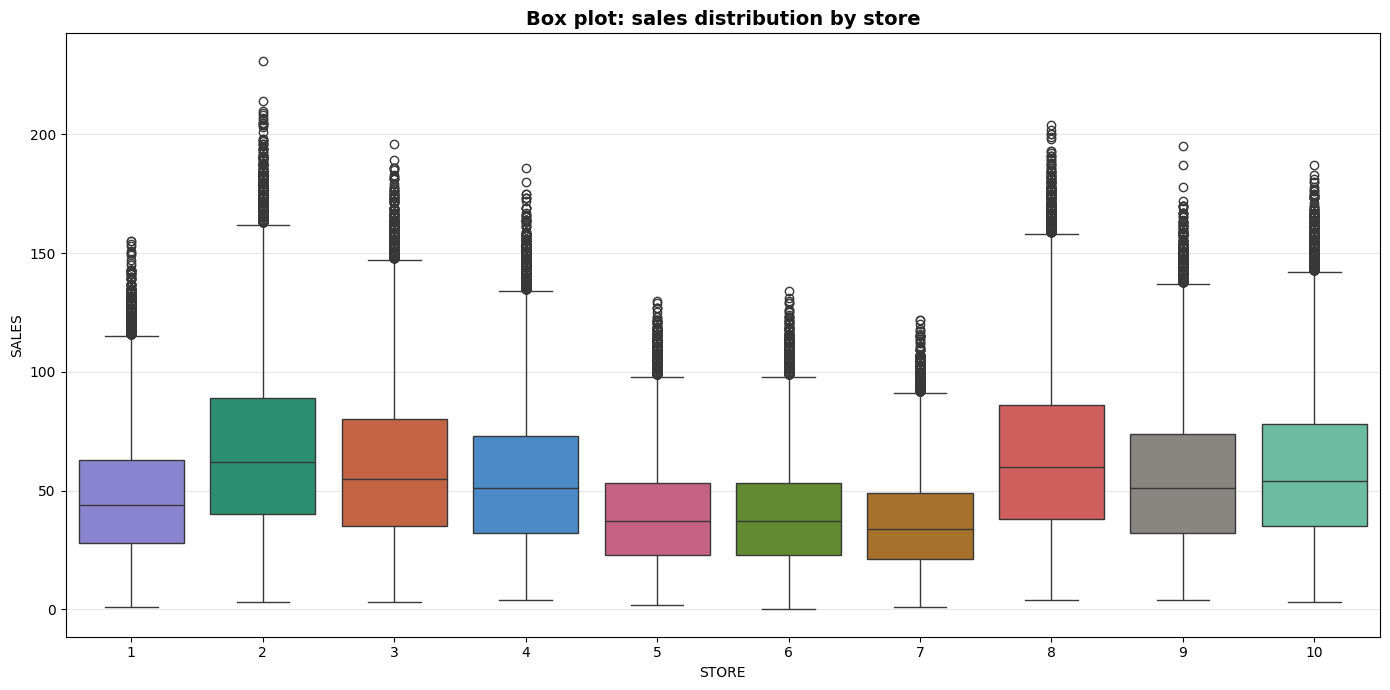

In [ ]:
PALETTE = [
    "#7F77DD", "#1D9E75", "#D85A30", "#378ADD", "#D4537E",
    "#639922", "#BA7517", "#E24B4A", "#888780", "#5DCAA5",
]

data["week"] = data.index.isocalendar().week.astype(int)
data["year"] = data.index.year
stores = sorted(data["store"].unique())

# ── DIAGRAM 1 — Heatmap ───────────────────────────────────────────────────────
pivot = data.groupby(["item", "store"])["sales"].mean().unstack()

plt.figure(figsize=(16, 10))
sns.heatmap(
    pivot,
    cmap="YlGnBu",
    linewidths=0.3,
    linecolor="white",
    cbar_kws={"label": "Average sales", "shrink": 0.6},
)
plt.title("Heatmap: average sales by item and store", fontsize=14, fontweight="bold")
plt.xlabel("STORE")
plt.ylabel("ITEM")
plt.tight_layout()
plt.show()

# ── DIAGRAM 2 — Linear dynamics ──────────────────────────────────────────────
selected_items = sorted(data["item"].unique())[:6]

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

for ax, item_id in zip(axes, selected_items):
    sub = data[data["item"] == item_id]
    for s_idx, store in enumerate(stores):
        store_data = sub[sub["store"] == store]
        weekly = store_data.groupby("week")["sales"].mean().sort_index()
        ax.plot(
            weekly.index, weekly.values,
            color=PALETTE[s_idx % len(PALETTE)],
            linewidth=1.8, alpha=0.85,
            label=f"Store {store}",
        )
    ax.set_title(f"Item {item_id}", fontsize=12, fontweight="bold")
    ax.set_xlabel("WEEK")
    ax.set_ylabel("SALES")
    ax.grid(alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=5, frameon=False)
fig.suptitle("Sales dynamics by week", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# ── DIAGRAM 3 — Box plot ───────────────────────────────────────────────────────
plt.figure(figsize=(14, 7))
sns.boxplot(data=data, x="store", y="sales", palette=PALETTE)
plt.title("Box plot: sales distribution by store", fontsize=14, fontweight="bold")
plt.xlabel("STORE")
plt.ylabel("SALES")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

Динаміка продажів відрізняється як між айтемами, так і між магазинами.
Загальний рівень продажів в середньому також відрізняється між магазинами.

Щодо айтемів, то ми можемо побачити з першого графіка, що 1,3,4,5,40,41,42,47,49 айтеми мають стабільно слабку динаміку продажів по всих магазинах.
Також магазини 1,5,6,7 стабільно показують низькі продажі по всих позиціях в порівнянні з іншими магазинами.
Що є досить цікавим для подальшого аналізу.

3. **Для початку проаналізуємо лише один ряд, а далі зможемо зациклити тренування моделей.**
  
  Виберіть підмножину даних, що відповідає продажам товару з `item == 1` у магазині з `store == 1`.

  Зробіть декомпозицію цього рядку за адитивною моделлю на тренд, сезонність і залишки з бібліотекою `statsmodels`.

  Зробіть висновки з отриманих візуалізацій. Чи щось би могло вам допомогти ліпше зрозуміти ці візуалізації? (з точки зору обробки даних)

In [ ]:
df_store1_it1 = data[(data['store'] == 1) & (data['item'] == 1)].sort_index()

In [ ]:
df_store1_it1.head()

,store,item,sales,week,year
date,,,,,
2013-01-01,1,1,13,1,2013
2013-01-02,1,1,11,1,2013
2013-01-03,1,1,14,1,2013
2013-01-04,1,1,13,1,2013
2013-01-05,1,1,10,1,2013


In [ ]:
print(df_store1_it1.shape)

(1826, 5)


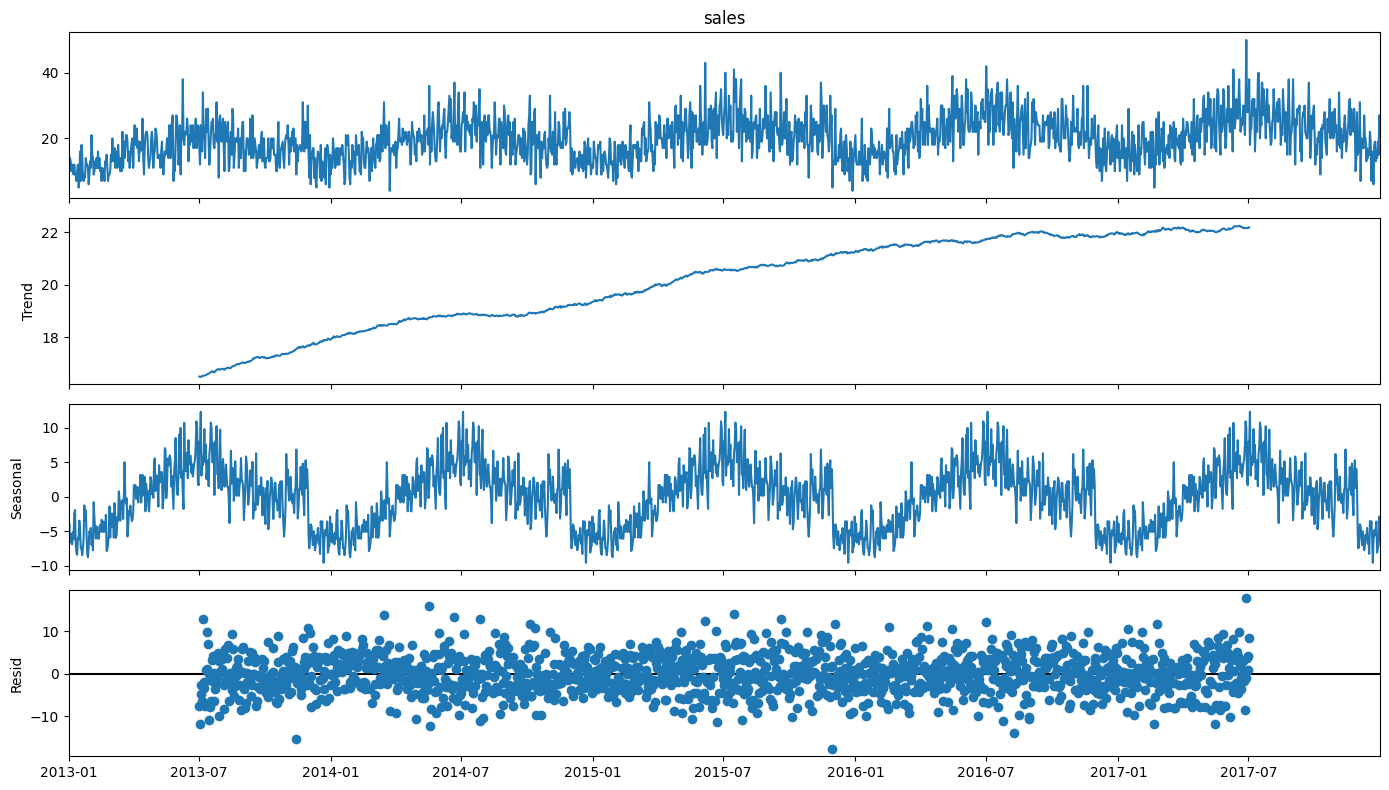

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

data = data.drop(columns=["week", "year"], errors="ignore")

decomposition = seasonal_decompose(
    df_store1_it1['sales'],
    model='additive',
    period=365
)

fig = decomposition.plot()
fig.set_size_inches(14, 8)
plt.tight_layout()
plt.show()

Графік Trend показує, що продажі Item_1 в Store_1 стабільно ростуть.
Сезонність впливає на продажі.
Залишки рівномірно розподілені відносно 0.

4. Зі створеної підмножини даних в попередньому пункті створіть обʼєкт класу `TimeSeries` в `darts` лише для колонки `sales`.

<Axes: xlabel='date'>

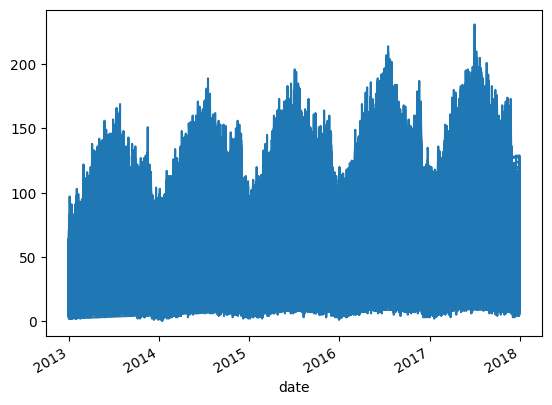

In [ ]:
data.sales.plot()

In [ ]:
!pip install darts --quiet

In [ ]:
df_store1_it1.head()

,store,item,sales,week,year
date,,,,,
2013-01-01,1,1,13,1,2013
2013-01-02,1,1,11,1,2013
2013-01-03,1,1,14,1,2013
2013-01-04,1,1,13,1,2013
2013-01-05,1,1,10,1,2013


In [ ]:
from darts import TimeSeries

df_store1_it1 = data[(data['store'] == 1) & (data['item'] == 1)].sort_index()

# Передаємо тільки колонку sales з датами як індексом
series = TimeSeries.from_dataframe(
    df_store1_it1[['sales']],
    fill_missing_dates=True,
    freq='D'
)

series

,sales
date,
2013-01-01,13.0
2013-01-02,11.0
2013-01-03,14.0
2013-01-04,13.0
2013-01-05,10.0
...,...
2017-12-27,14.0
2017-12-28,19.0
2017-12-29,15.0


<Axes: xlabel='date'>

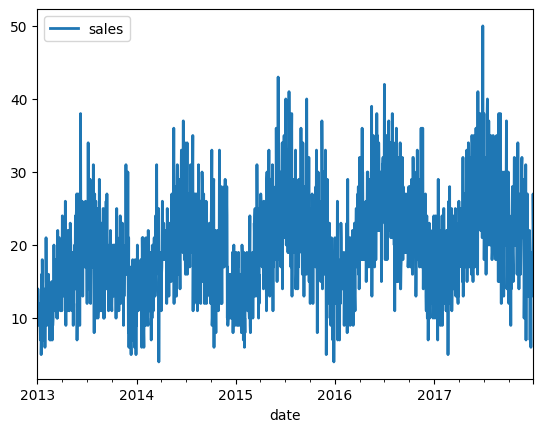

In [ ]:
series.plot()

5. Використовуючи метод `series.split_before` розбийте дані на тренування і валідацію так, аби валідація починалась з `2017-10-01` включно.

  Візуалізуйте на одному графіку тренувальну і валідаційну частину як було показано в лекції.

<Axes: xlabel='date'>

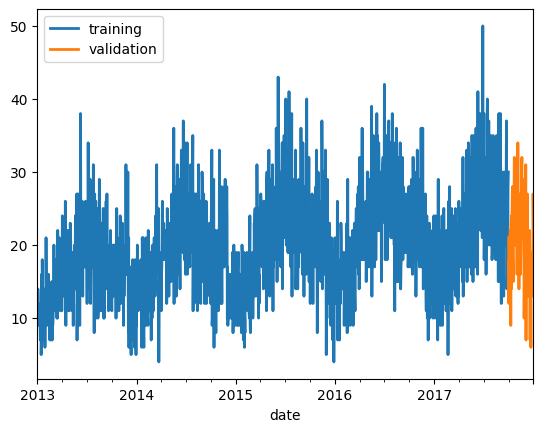

In [ ]:
train, val = series.split_before(pd.Timestamp("2017-10-01"))
train.plot(label="training")
val.plot(label="validation")


6. Побудуйте часткову автокореляційну фукнцію для цього нашого ряду в `series`. Напишіть висновки - які лаги є важливими для прогнозування?

<Figure size 1000x400 with 0 Axes>

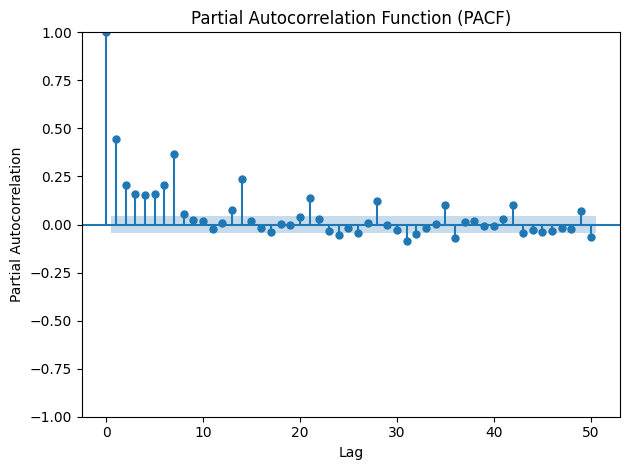

In [ ]:
from statsmodels.graphics.tsaplots import plot_pacf

plt.figure(figsize=(10, 4))
plot_pacf(
    df_store1_it1['sales'],
    lags=50,
    method='ywm'
)
plt.title('Partial Autocorrelation Function (PACF)')
plt.xlabel('Lag')
plt.ylabel('Partial Autocorrelation')
plt.tight_layout()
plt.show()

Для прогнозування важливими є lag 1, 7, 14.

<Figure size 1000x400 with 0 Axes>

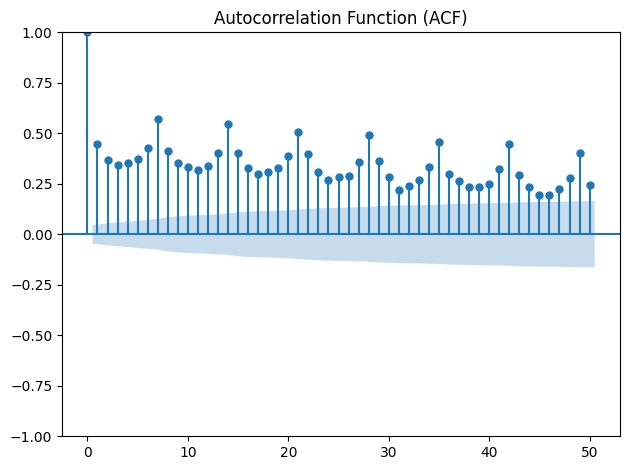

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(10, 4))
plot_acf(df_store1_it1['sales'], lags=50)
plt.title('Autocorrelation Function (ACF)')
plt.tight_layout()
plt.show()

In [ ]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df_store1_it1['sales'])
print(f"ADF статистика: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")
print("Ряд стаціонарний" if result[1] < 0.05 else "Ряд НЕ стаціонарний")

ADF статистика: -3.1577
p-value: 0.0226
Ряд стаціонарний


7. Виявіть сезональність тренувального ряду використовуючи фукнкцію `check_seasonality` з `darts`.

In [ ]:
from darts.utils.statistics import check_seasonality

for m in range (2, 25):
     is_seasonal, period = check_seasonality(series, m=m, alpha=0.05)
     if is_seasonal:
      print("There is seasonality of order {}.".format(period))

There is seasonality of order 7.
There is seasonality of order 14.
There is seasonality of order 21.


8. Побудуйте наївну модель NaiveSeasonal + NaieDrift для прогнозування даних. Кількість кроків для прогнозування визначіть зі свого аналізу в попередніх пунктах. Візуалізайте передбачення проти справжніх даних так, аби було видно якість передбачень. Зробіть висновок про модель. Вона точна?

  Якщо у вас є ідеї, як поліпшити якість передбачення саме наївними моделями - реалізуйте їх в цьому пункті :)

In [ ]:
!pip install pytorch-lightning -q

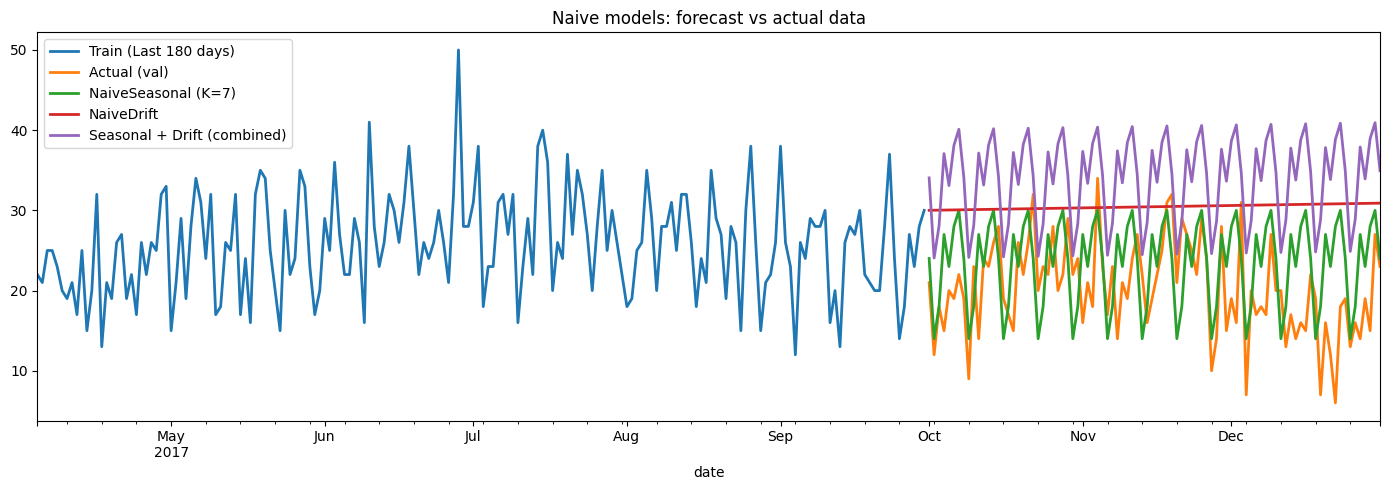

In [ ]:
from darts.models import NaiveSeasonal, NaiveDrift
from darts.metrics import mape, mae

n = len(val)

# Training the NaiveSeasonal model
seasonal_model = NaiveSeasonal(K=7)  # K=7 because PACF showed weekly seasonality
seasonal_model.fit(train)
seasonal_forecast = seasonal_model.predict(n)

#Training the NaieDrift model
drift_model = NaiveDrift()
drift_model.fit(train)
drift_forecast = drift_model.predict(n)

train_mean = train.univariate_values().mean()
combined_forecast = seasonal_forecast + drift_forecast - train_mean

# Visualization
plt.figure(figsize=(14, 5))
train[-180:].plot(label="Train (Last 180 days)")
val.plot(label="Actual (val)")
seasonal_forecast.plot(label=f"NaiveSeasonal (K=7)")
drift_forecast.plot(label="NaiveDrift")
combined_forecast.plot(label="Seasonal + Drift (combined)")
plt.title("Naive models: forecast vs actual data")
plt.legend()
plt.tight_layout()
plt.show()

Наївні моделі не справляються з прогнозуванням цього ряду. NaiveSeasonal (K=7) вловлює тижневий ритм коливань, але не відображає спадаючу динаміку кінця року, яку ми спостерігали в частковій автокореляції.

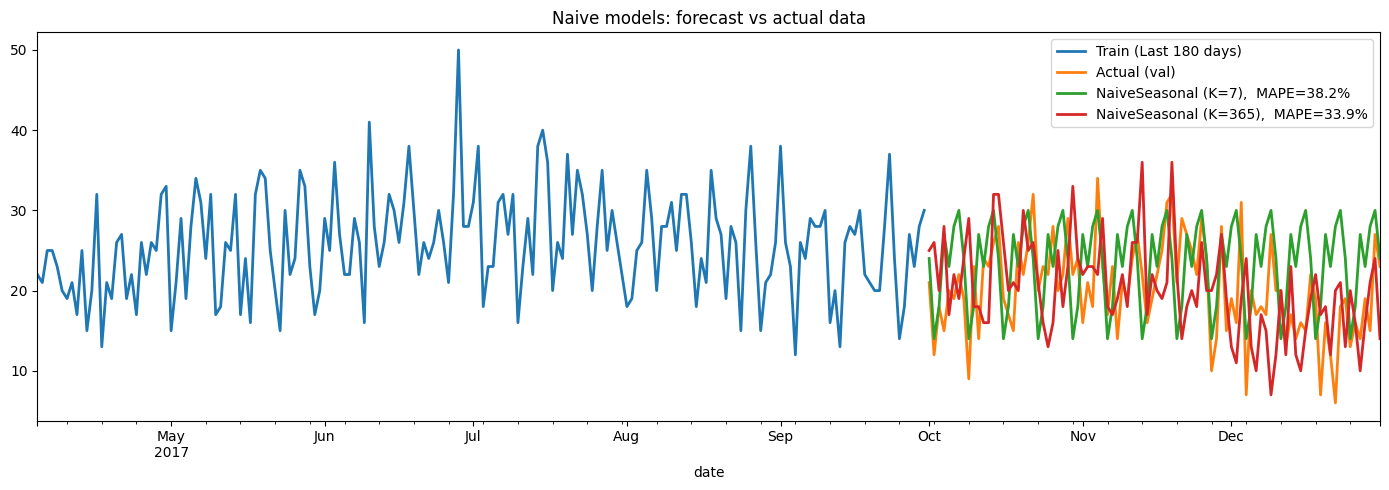

In [ ]:
plt.figure(figsize=(14, 5))
train[-180:].plot(label="Train (Last 180 days)")
val.plot(label="Actual (val)")

for k in [7, 365]:
    m = NaiveSeasonal(K=k)
    m.fit(train)
    pred = m.predict(n)
    pred.plot(label=f"NaiveSeasonal (K={k}),  MAPE={mape(val, pred):.1f}%")

plt.title("Naive models: forecast vs actual data")
plt.legend()
plt.tight_layout()
plt.show()

K = 365 краще відображає річну сезонність.

9. Обчисліть помилку прогнозу на валідації наївною моделлю з mape. Далі для всіх моделей необхідно обчислювати помилку прогнозу на валідації.

In [ ]:
# Порахую метрики для тижневої сезонності, K = 7, що ми використовували для прогнозування
print(f"NaiveSeasonal  MAPE: {mape(val, seasonal_forecast):.2f}%")
print(f"NaiveDrift     MAPE: {mape(val, drift_forecast):.2f}%")
print(f"Combined       MAPE: {mape(val, combined_forecast):.2f}%")

NaiveSeasonal  MAPE: 38.17%
NaiveDrift     MAPE: 68.74%
Combined       MAPE: 84.34%


Помилки досить високі. А, NaiveDrift взагалі не підходить для прогнозу даних при сезонності, що в нас є.



In [ ]:
# Спробуємо перевірити помилки на інших частотах сезонності.
for k in [7, 14, 30, 365]:
    m = NaiveSeasonal(K=k)
    m.fit(train)
    pred = m.predict(n)
    print(f"K={k:3d}  MAPE: {mape(val, pred):.2f}%")

K=  7  MAPE: 38.17%
K= 14  MAPE: 40.24%
K= 30  MAPE: 51.50%
K=365  MAPE: 33.92%


Найкраще спрацьовує річна сезонність

10. Натренуйте XBGModel з `darts` для передбачення наших даних. Можна додавати всі додаткові ознаки, які вважаєте за потрібне, наприклад, ознаки з дати. Зробіть висновок про якість моделі.

XGBModel MAPE:      27.08%
NaiveSeasonal MAPE: 33.92%  (K=365, for comparison)


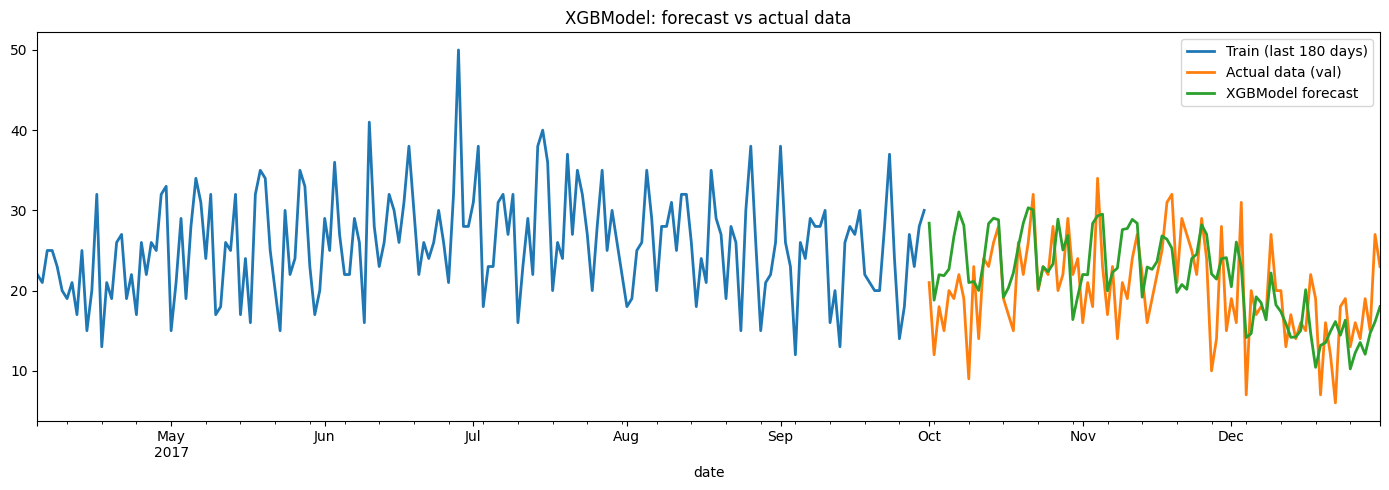

In [ ]:
from darts.models import XGBModel
from darts.dataprocessing.transformers import Scaler
from darts.utils.timeseries_generation import datetime_attribute_timeseries
from darts.metrics import mape

# Additional signs from the date
def get_covariates(series):
    month     = datetime_attribute_timeseries(series, attribute="month", one_hot=False)
    weekday   = datetime_attribute_timeseries(series, attribute="weekday", one_hot=False)
    dayofyear = datetime_attribute_timeseries(series, attribute="dayofyear", one_hot=False)
    week      = datetime_attribute_timeseries(series, attribute="week", one_hot=False)

    from darts import concatenate
    return concatenate([month, weekday, dayofyear, week], axis=1)

covariates = get_covariates(series)

# Scaling
scaler = Scaler()
train_scaled = scaler.fit_transform(train)
val_scaled   = scaler.transform(val)

# Covariate breakdown
cov_train = covariates[:len(train)]
cov_val   = covariates  # передаємо весь ряд

# Model
model = XGBModel(
    lags=30,                    # останні 30 днів
    lags_future_covariates=[0], # поточні значення ознак
    output_chunk_length=1,
)

model.fit(
    train_scaled,
    future_covariates=cov_train,
)

# Forecast
n = len(val)
pred_scaled = model.predict(n, future_covariates=cov_val)
pred = scaler.inverse_transform(pred_scaled)

# Metrics
print(f"XGBModel MAPE:      {mape(val, pred):.2f}%")
print(f"NaiveSeasonal MAPE: 33.92%  (K=365, for comparison)")

# Visualization
plt.figure(figsize=(14, 5))
train[-180:].plot(label="Train (last 180 days)")
val.plot(label="Actual data (val)")
pred.plot(label=f"XGBModel forecast")
plt.title("XGBModel: forecast vs actual data")
plt.legend()
plt.tight_layout()
plt.show()

У порівнянні з найкращими моделями NaiveSeasonal K = 365, модель  XGBModel показала покращення

11. Натренуйте модель ExponentialSmoothing та зробіть висновок про її якість.

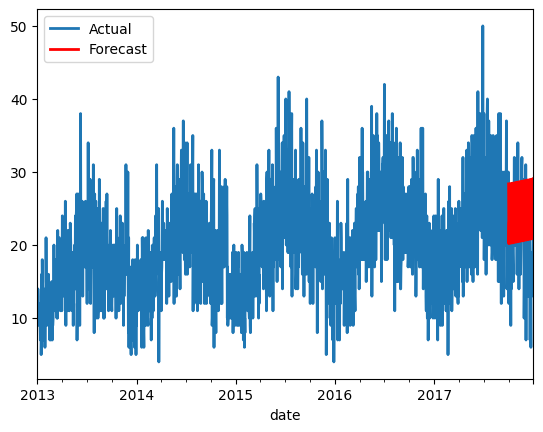

Model:  ExponentialSmoothing
MAPE:   39.01%
MAE:    5.71
------------------------------


In [ ]:
from darts.models import ExponentialSmoothing, AutoARIMA, Theta

def eval_forecast(model, val, forecast):
    print(f"Model:  {model.__class__.__name__}")
    print(f"MAPE:   {mape(val, forecast):.2f}%")
    print(f"MAE:    {mae(val, forecast):.2f}")
    print("-" * 30)

def plot_results(series, forecast):
    series.plot(label="Actual")
    forecast.plot(label="Forecast", color="red")
    plt.legend()
    plt.show()

def fit_and_plot(model, series, train, val):
  model.fit(train)
  forecast = model.predict(len(val))
  plot_results(series, forecast)
  eval_forecast(model, val, forecast);

model = ExponentialSmoothing()
fit_and_plot(model, series, train, val)

Модель показала гірший результат за XGBModel та NaiveSeasonal (K=365), навіть NaiveSeasonal (K=7) був 38.17%.

12. Натренуйте модель ARIMA, параметри оберіть самостійно.Зробіть висновок про її якість.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


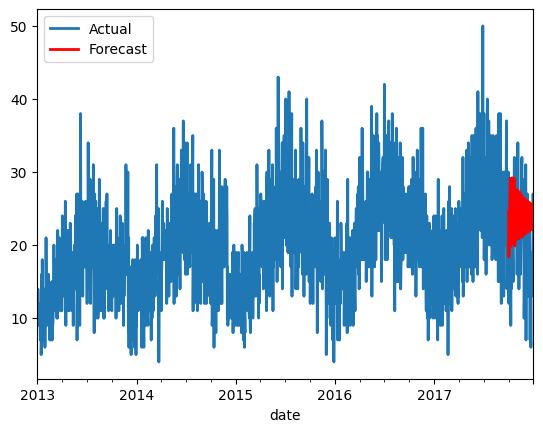

Model:  ARIMA
MAPE:   36.76%
MAE:    5.46
------------------------------


In [ ]:
from darts.models import ARIMA

model = ARIMA(p=30, d=1, q=1)
fit_and_plot(model, series, train, val)

13. Знайдіть оптимальні параметри моделі ARIMA з допомогою AutoARIMA моделі. Виконайте пошук параметрів, виведіть, які паарметри виявились оптимальними і обчисліть якість моделі. Чи поліпшилась якість порівняно з попереднім експериментом?

In [ ]:
!pip install statsforecast -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.6/354.6 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.2/348.2 kB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.0/281.0 kB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 kB 4.7 MB/s eta 0:00:00


Оптимальні параметри AutoARIMA:
ARIMA(4, 1, 1)(0, 0, 2)[7]

AutoARIMA MAPE: 40.56%


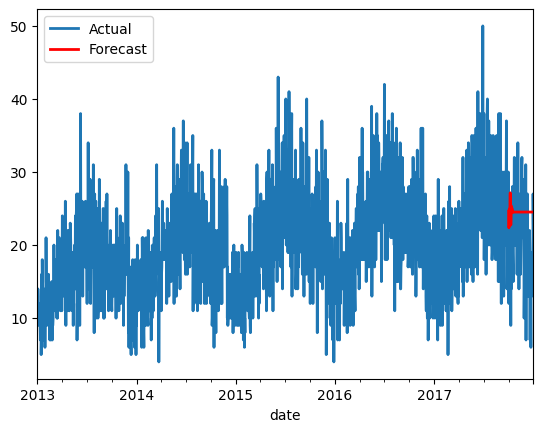

In [ ]:
model = AutoARIMA(
    add_encoders=None,
    start_p=7,
    max_p=30,
    start_q=1,
    max_q=3,
    season_length=7
)

model.fit(train)
arma = fitted['arma']
print(f"Оптимальні параметри AutoARIMA:")
print(f"ARIMA({arma[0]}, {arma[5]}, {arma[1]})({arma[2]}, {arma[6]}, {arma[3]})[{arma[4]}]")

forecast = model.predict(len(val))

# Quality
print(f"\nAutoARIMA MAPE: {mape(val, forecast):.2f}%")

# Visualisation
plot_results(series, forecast)

SARIMAX MAPE: 38.04%
AutoARIMA MAPE: 40.56%  (для порівняння)
XGBModel  MAPE: 27.08%  (для порівняння)


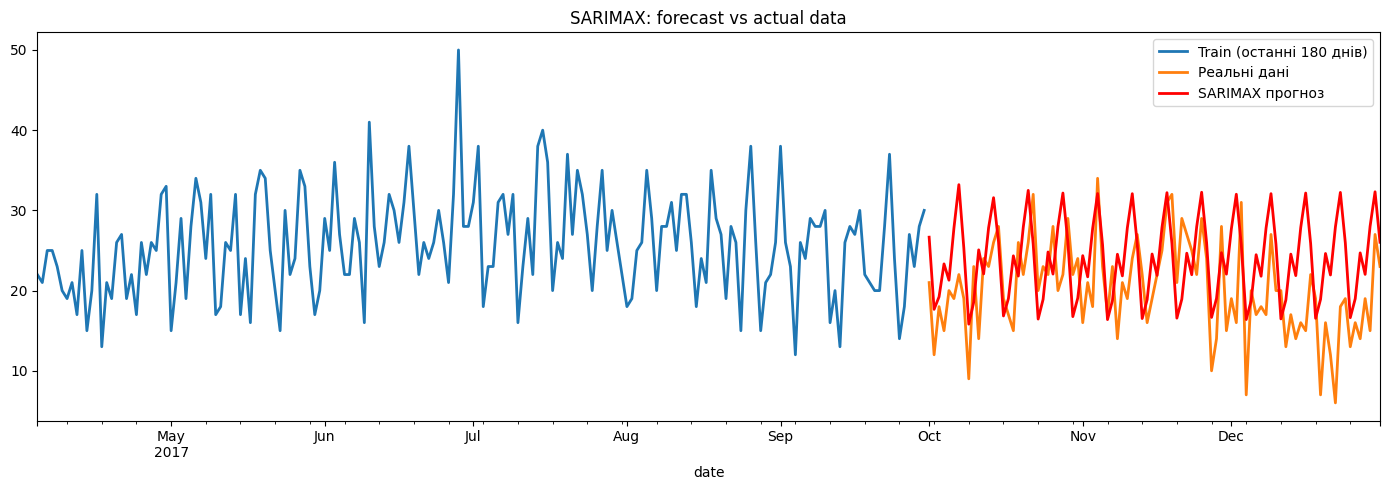

In [ ]:
# Екзогенна змінна — ознаки з дати
exog = pd.DataFrame({
    'weekday':   df_store1_it1.index.weekday,
    'month':     df_store1_it1.index.month,
    'dayofyear': df_store1_it1.index.dayofyear,
}, index=df_store1_it1.index)

exog_series = TimeSeries.from_dataframe(exog, fill_missing_dates=True, freq='D')

# Поділ екзогенних змінних так само як train/val
train_exog, val_exog = exog_series.split_before(pd.Timestamp('2017-10-01'))

# Модель SARIMAX з тижневою сезонністю
model = ARIMA(1, 0, 1, seasonal_order=(1, 1, 0, 7))
model.fit(train, future_covariates=train_exog)

# Прогноз
forecast = model.predict(len(val), future_covariates=exog_series)

# Якість
print(f"SARIMAX MAPE: {mape(val, forecast):.2f}%")
print(f"AutoARIMA MAPE: 40.56%  (для порівняння)")
print(f"XGBModel  MAPE: 27.08%  (для порівняння)")

# Візуалізація
plt.figure(figsize=(14, 5))
train[-180:].plot(label="Train (останні 180 днів)")
val.plot(label="Реальні дані")
forecast.plot(label="SARIMAX прогноз", color="red")
plt.title("SARIMAX: forecast vs actual data")
plt.legend()
plt.tight_layout()
plt.show()

ARIMA, SARIMAX, ExponentialSmoothing не справляються з цим рядом краще за просту наївну модель. XGBModel з ознаками з дати дає найкращий результат — 27% mape.

14. Натренуйте модель Prophet та зробіть висновок про її якість.

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


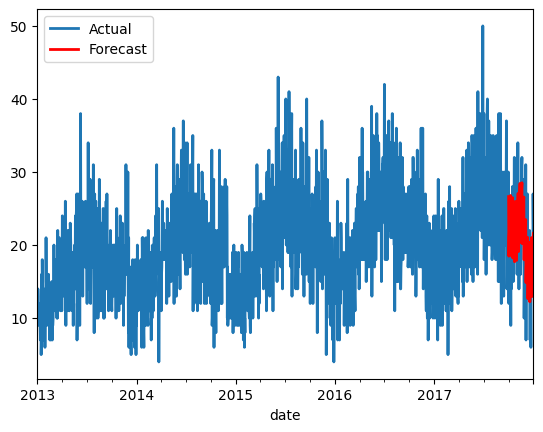

Model:  Prophet
MAPE:   23.80%
MAE:    3.83
------------------------------


In [ ]:
from darts.models import Prophet

model = Prophet()
model.fit(train)

forecast = model.predict(len(val))

series.plot(label="Actual")
forecast.plot(label="Forecast", color="red")
plt.legend()
plt.show()

eval_forecast(model, val, forecast);

Prophet дає найкращий результат.

15. Натренуйте модель `RNNModel` та зробіть висновок про її якість.

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ criterion       │ MSELoss          │      0 │ train │     0 │
│ 1 │ train_criterion │ MSELoss          │      0 │ train │     0 │
│ 2 │ val_criterion   │ MSELoss          │      0 │ train │     0 │
│ 3 │ train_metrics   │ MetricCollection │      0 │ train │     0 │
│ 4 │ val_metrics     │ MetricCollection │      0 │ train │     0 │
│ 5 │ rnn             │ LSTM             │  2.8 K │ train │     0 │
│ 6 │ V               │ Linear           │     26 │ train │     0 │
└───┴─────────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 2.8 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.8 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 7                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=100` reached.


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

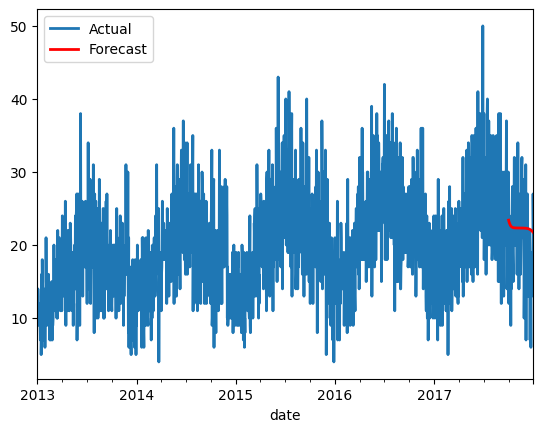

Model:  RNNModel
MAPE:   33.21%
MAE:    4.97
------------------------------


In [ ]:
from darts.models import RNNModel

model = RNNModel(
    model="LSTM",
    input_chunk_length=365,
    training_length=400,
    output_chunk_length=1,
    n_epochs=100,
    batch_size=32
)

model.fit(train)

forecast = model.predict(len(val))

series.plot(label="Actual")
forecast.plot(label="Forecast", color="red")
plt.legend()
plt.show()

eval_forecast(model, val, forecast);

LSTM (100 epochs)=33.21% - схоже стався оверфіт. Модель погіршилась трохи в порівнянні з 10 epochs.
Як на мене модель спрацювала погано. Можливо параметри не вірно підібрані.

16. Виконайте бектест для тої моделі, яка виявилась найкращою у вашому дослідженні на періоді 1 рік з передбаченнями на 1 місяць щоразу. Візуалізуйте як поводилась модель протягом бектесту, яка була точність?

In [54]:
model = Prophet()
model.fit(train)
forecast = model.predict(len(val))
eval_forecast(model, val, forecast);

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Model:  Prophet
MAPE:   23.80%
MAE:    3.83
------------------------------


historical forecasts: 100%|██████████| 336/336 [02:00<00:00,  2.78it/s]


MAPE = 20.37%


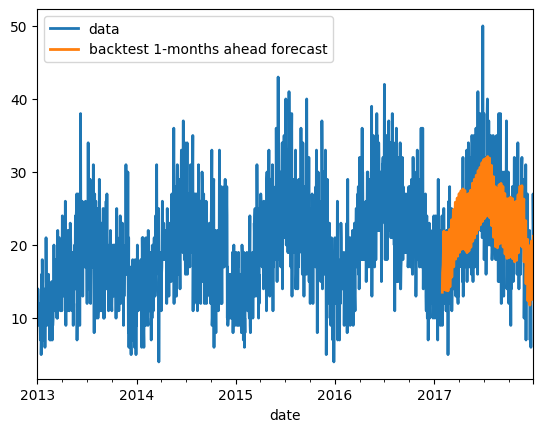

In [55]:
hfc_params = {
    "series": series,
    "start": pd.Timestamp("2017-01-01"),
    "forecast_horizon": 30,
    "verbose": True,
}

historical_fcast = model.historical_forecasts(last_points_only=True, **hfc_params)

series.plot(label="data")
historical_fcast.plot(label="backtest 1-months ahead forecast")
print(f"MAPE = {mape(series, historical_fcast):.2f}%")

Бектест перевірив модель 336 разів на різних часових відрізках, а не один раз.

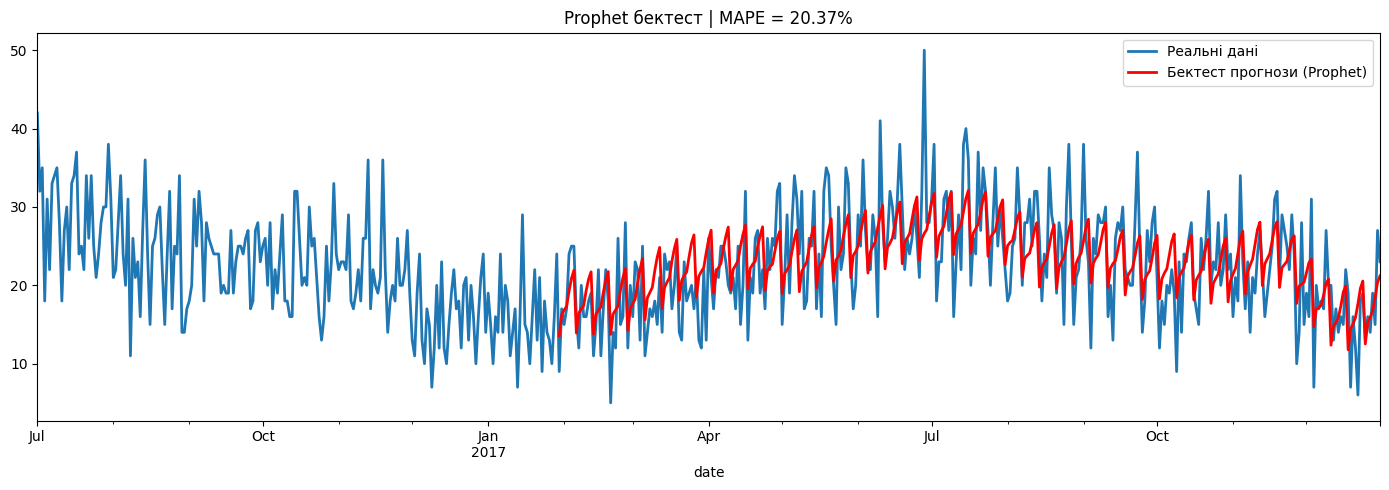

In [56]:
plt.figure(figsize=(14, 5))
series[pd.Timestamp("2016-07-01"):].plot(label="Реальні дані")
historical_fcast.plot(label="Бектест прогнози (Prophet)", color="red")
plt.title(f"Prophet бектест | MAPE = 20.37%")
plt.legend()
plt.tight_layout()
plt.show()

Prophet показав mape 20.37% на бектесті за 2017 рік з прогнозами на 1 місяць вперед. Це найкращий результат серед усіх протестованих моделей. Модель стабільно відтворює сезонні патерни протягом року — як тижневу так і річну сезонність. Точність можна вважати прийнятною для задачі прогнозування продажів, але є простір для покращення через тюнінг гіперпараметрів або додаванням додаткових параметрів.

In [60]:
average_error = model.backtest(
    metric=mape,
    reduction=np.mean,  # this is actually the default
    **hfc_params
)

print(f"Average error (MAPE) over all historical forecasts: {average_error:.2f}")

historical forecasts: 100%|██████████| 336/336 [02:07<00:00,  2.65it/s]

Average error (MAPE) over all historical forecasts: 20.43


In [61]:
hfc_precomputed = model.historical_forecasts(last_points_only=False, stride=1, **hfc_params)
new_error = model.backtest(historical_forecasts=hfc_precomputed, last_points_only=False, stride=1, **hfc_params)

print(f"Average error (MAPE) over all historical forecasts: {new_error:.2f}")

historical forecasts: 100%|██████████| 336/336 [02:15<00:00,  2.48it/s]

Average error (MAPE) over all historical forecasts: 20.43


INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 1.
INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 2.
INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality

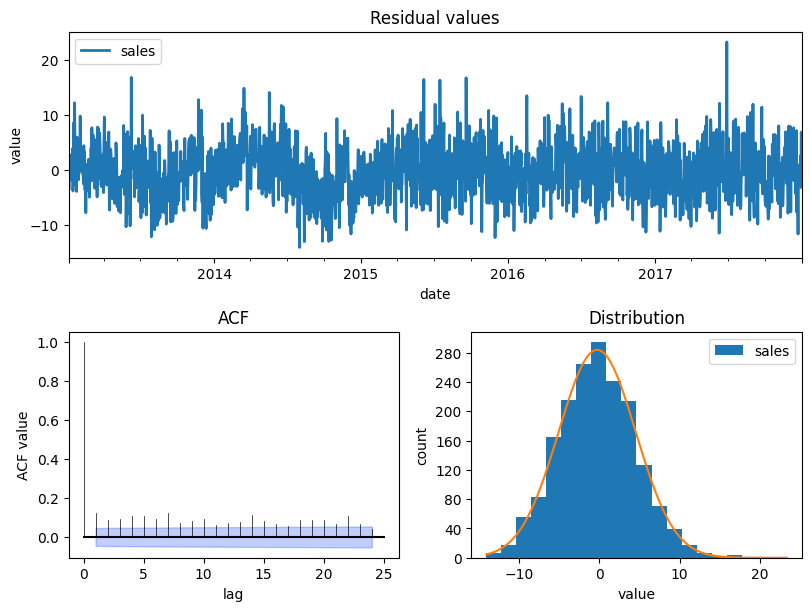

In [62]:
#Залишки
from darts.utils.statistics import plot_residuals_analysis

plot_residuals_analysis(model.residuals(series))

Text(0.5, 1.0, 'Absolute errors per forecast step')

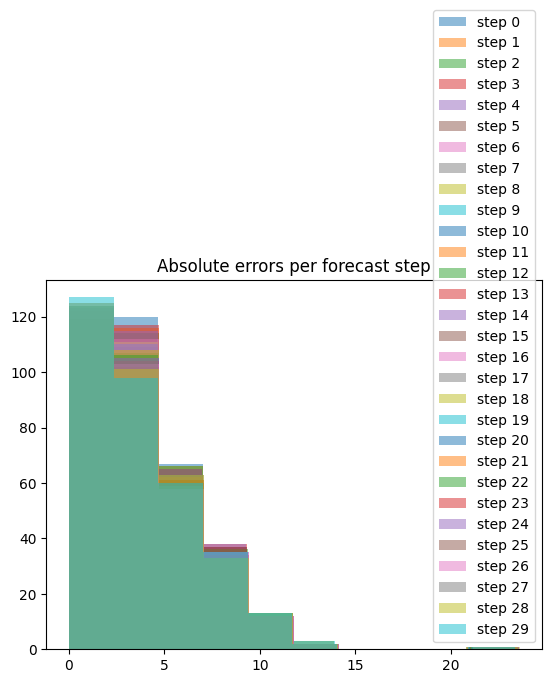

In [63]:
# Тепер давайте перевіримо розподіл абсолютних помилок, які ми отримуємо для кожного кроку в прогнозах на 1 місяць.
from darts.metrics import ae
residuals = model.residuals(
    historical_forecasts=hfc_precomputed,
    metric=ae,  # the absolute error per time step
    last_points_only=False,
    values_only=True, # return a list of numpy arrays
    **hfc_params
)
residuals = np.concatenate(residuals, axis=1)[:, :, 0]

fig, ax = plt.subplots()
for forecast_step in range(len(residuals)):
    ax.hist(residuals[forecast_step], label=f"step {forecast_step}", alpha=0.5)
ax.legend()
ax.set_title("Absolute errors per forecast step")

Всю варіантивність не вгадали, але виглядає непогано!

17. На цьому етапі ви зрозуміли, як моделювати продажі одного айтему з 1 магазину. Як би ви підійшли до задачі прогнозування продажів в наступному місяці для кожного з 50 айтемів в кожному з 10 магазинів? Опишіть загальний підхід
- яку модель ви б використали
- скільки моделей ви б тренували
- обгрунтуйте свій вибір.

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:144: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.encoder = TransformerEncoder(
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name                ┃ Type                ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ criterion           │ MSELoss             │      0 │ train │     0 │
│ 1 │ train_criterion     │ MSELoss             │      0 │ train │     0 │
│ 2 │ val_criterion       │ MSELoss             │      0 │ train │     0 │
│ 3 │ train_metrics       │ MetricCollection    │      0 │ train │     0 │
│ 4 │ val_metrics         │ MetricCollection    │      0 │ train │     0 │
│ 5 │ encoder             │ Linear              │    128 │ train │     0 │
│ 6 │ positional_encoding │ _PositionalEncoding │      0 │ train │     0 │
│ 7 │ transformer         │ Transformer         │  548 K │ train │     0 │
│ 8 │ decoder             │ Linear              │     65 │ train │     0 │
└───┴─────────────────────┴─────────────────────┴────────┴───────┴───────┘

Trainable params: 548 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 548 K                                                                                                
Total estimated model params size (MB): 4                                                                          
Modules in train mode: 88                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

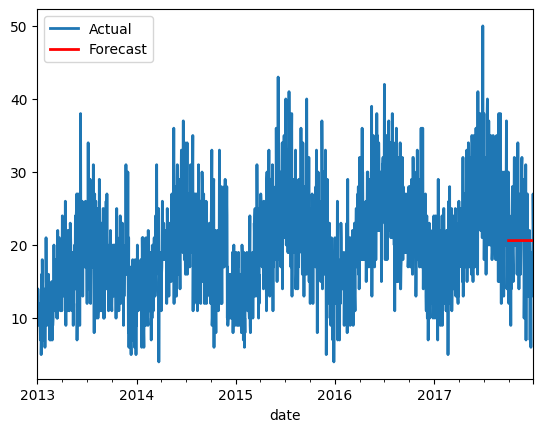

In [65]:
from darts.models import TransformerModel

# Побудова та тренування моделі трансформера
model = TransformerModel(input_chunk_length=30, output_chunk_length=1, n_epochs=10)
model.fit(train)

# Прогнозування
forecast = model.predict(len(val))

# Візуалізація результатів
series.plot(label='Actual')
forecast.plot(label='Forecast', color='red')
plt.legend()
plt.show()

In [66]:
eval_forecast(model, val, forecast)

Model:  TransformerModel
MAPE:   29.37%
MAE:    4.66
------------------------------


Для кожного магазину прогноз робимо окремою моделлю.
Модель потрібно обирати таку, яка краще справляється з трендом та сезонністю в нашому випадку з товарами в магазинах. Prophet, XGBModel, LSTM, SARIMAX. Але в кожному випадку потрібно робити тюнінг гіперпараметрів для отримання якісного результату.
Я б тренувала ці моделі і трансформери(коли я з ними розберусь=) ).

XGBModel здатний обробляти складні залежності та великі обсяги даних. А, 10 магазинів та 50 айтемів - це вже не мало. Хоча, аналізуючи як я один товар аналізувала тут в одному магазині, можливо я б пошукала ще й інші моделі, які саме краще працюють з товарами, сезонністю та обробкою великого обсягу даних.